In [1]:
from sklearn import datasets

digits = datasets.load_digits()

print(digits.images.shape)  
print(digits.data.shape)
print(digits.target.shape)
print(digits.target[:10])

(1797, 8, 8)
(1797, 64)
(1797,)
[0 1 2 3 4 5 6 7 8 9]


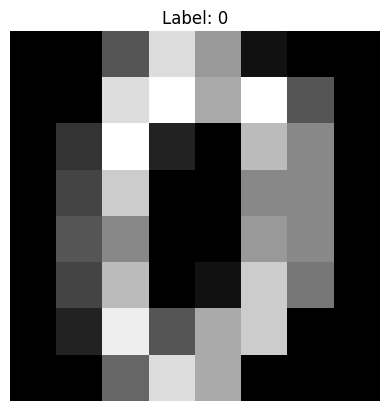

In [2]:
import matplotlib.pyplot as plt

plt.imshow(digits.images[0], cmap='gray')
plt.title(f'Label: {digits.target[0]}')
plt.axis('off')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(1437, 64) (360, 64)


In [4]:
from sklearn.svm import SVC

clf = SVC(gamma=0.001)
clf.fit(X_train, y_train)

predicted = clf.predict(X_test)
print(predicted[:10])
print(y_test[:10])

[6 9 3 7 2 1 5 2 5 2]
[6 9 3 7 2 1 5 2 5 2]


In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
print(classification_report(y_test, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      0.97      0.99        34
           4       1.00      1.00      1.00        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       0.97      0.97      0.97        34
           8       1.00      1.00      1.00        30
           9       0.97      0.97      0.97        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



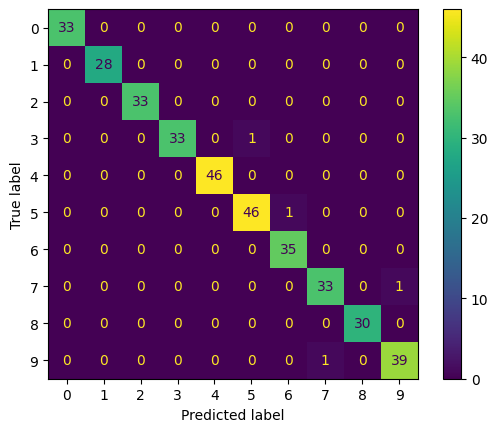

In [6]:
ConfusionMatrixDisplay.from_predictions(y_test, predicted)
plt.show()

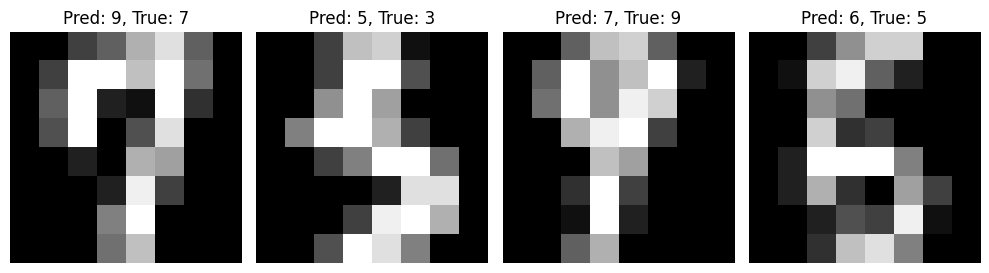

In [7]:
wrong = (predicted != y_test)

fig, axes = plt.subplots(1, sum(wrong), figsize=(10, 3))
for ax, image, pred, true in zip(
    axes, 
    X_test[wrong].reshape(-1, 8, 8),
    predicted[wrong],
    y_test[wrong]
):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Pred: {pred}, True: {true}')
    ax.axis('off')

plt.tight_layout()
plt.show()